In [1]:
!git clone https://github.com/Hamzaabba2005/Dissertation.git

Cloning into 'Dissertation'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 114 (delta 14), reused 25 (delta 9), pack-reused 84 (from 1)
Receiving objects: 100% (114/114), 30.39 MiB | 28.52 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [2]:
import sys
sys.path.append("/kaggle/working/Dissertation/src")

In [3]:
# configuration
from config import *

# reproducibility
from reproducibility import seed_everything

# dataset utilities
from auto_detect import pick_images_dir
from build_samples import build_samples_existing
from patient_level_split import patient_level_split

# transforms
from transforms_config import get_transforms

# dataloaders
from dataset import create_dataloaders

# class imbalance handling
from class_weights import compute_pos_weight

# models
from model import build_model

from thresholds import (
    tune_thresholds_per_class,
    predict_with_thresholds,
    evaluate_with_thresholds,
    threshold_report,
)


In [4]:
import os
import random
import copy
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score

In [5]:
from config import *

BASE_PATH = os.getenv("DATASET_PATH", "/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k")
CSV_PATH = os.path.join(BASE_PATH, "full_df.csv")
IMAGES_DIR = os.path.join(BASE_PATH, "preprocessed_images")

print("CSV exists:", os.path.exists(CSV_PATH))
print("Images dir exists:", os.path.exists(IMAGES_DIR))
print("Device:", DEVICE)

CSV exists: True
Images dir exists: True
Device: cuda


In [6]:
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
Device count: 1
Current device: 0
GPU name: Tesla P100-PCIE-16GB


In [7]:
from reproducibility import seed_everything

SEED = 42
seed_everything(SEED)

In [8]:
df = pd.read_csv(CSV_PATH)
print("CSV shape:", df.shape)
(df.head())

CSV shape: (6392, 19)


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


In [9]:
from auto_detect import pick_images_dir

auto_dir, hits = pick_images_dir(BASE_PATH, df)

if auto_dir is not None and hits > 0:
    IMAGES_DIR = auto_dir

print("Selected IMAGES_DIR:", IMAGES_DIR)
print("Hits:", hits)

Selected IMAGES_DIR: /kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images
Hits: 39


In [10]:
from build_samples import build_samples_existing

samples, missing, bad_labels = build_samples_existing(
    df,
    IMAGES_DIR,
    LABEL_COLS
)

print("Total usable samples:", len(samples))
print("Missing images:", missing)
print("Bad label rows:", bad_labels)

Total usable samples: 12460
Missing images: 324
Bad label rows: 0


In [11]:
from patient_level_split import patient_level_split

train_samples, val_samples = patient_level_split(
    samples,
    VAL_SIZE,
    SEED
)

train_patients = set(s["patient_id"] for s in train_samples)
val_patients = set(s["patient_id"] for s in val_samples)

print("Train samples:", len(train_samples))
print("Val samples:", len(val_samples))
print("Unique train patients:", len(train_patients))
print("Unique val patients:", len(val_patients))
print("Patient overlap:", len(train_patients & val_patients))


Train samples: 10609
Val samples: 1851
Unique train patients: 2854
Unique val patients: 504
Patient overlap: 0


In [12]:
from transforms_config import get_transforms

train_tfm, val_tfm = get_transforms(IMG_SIZE)

In [13]:
from torch.utils.data import DataLoader
from dataset import create_dataloaders

train_ds, val_ds, train_loader, val_loader = create_dataloaders(
    train_samples,
    val_samples,
    train_tfm,
    val_tfm
)

train_loader = DataLoader(
    train_ds,
    batch_size=TRAIN_BS,
    shuffle=True,
    num_workers=4,        
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=VAL_BS,
    shuffle=False,
    num_workers=4,      
    pin_memory=True
)

print("Dataloaders recreated with num_workers=0")
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Dataloaders recreated with num_workers=0
Train batches: 664
Val batches: 58


In [14]:
from class_weights import compute_pos_weight

pos_weight = compute_pos_weight(train_samples).to(DEVICE)
print("pos_weight:", pos_weight)

pos_weight: tensor([ 2.0054,  1.9486, 15.4481, 14.5102, 19.0170, 30.9548, 20.0496,  3.3640],
       device='cuda:0')


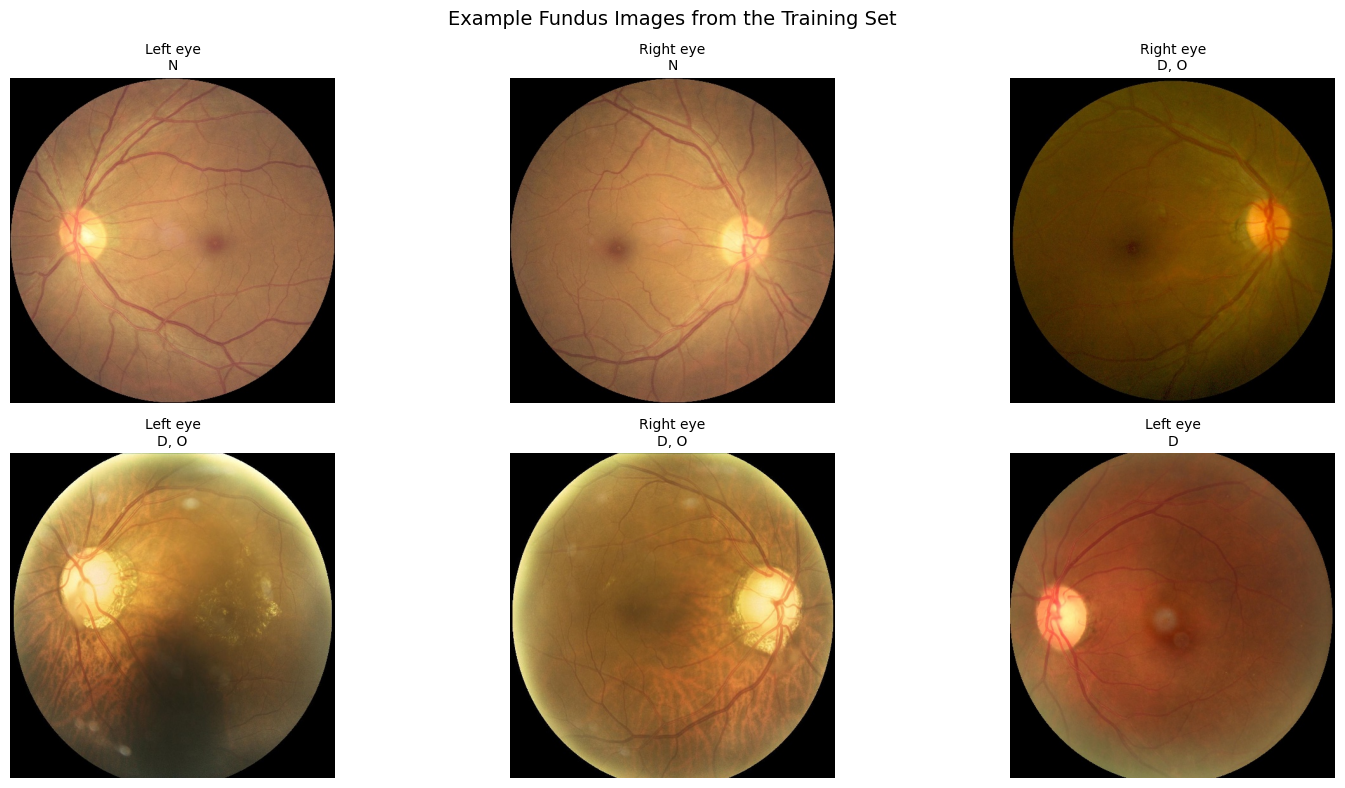

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

def show_sample_images(samples, n=6):
    n = min(n, len(samples))
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(16, 8))
    axes = np.array(axes).reshape(-1)

    for ax, sample in zip(axes, samples[:n]):
        img = Image.open(sample["path"]).convert("RGB")
        ax.imshow(img)
        positive_labels = [LABEL_COLS[i] for i, v in enumerate(sample["label"]) if v > 0]
        ax.set_title(f"{sample['side']} eye\n" + ", ".join(positive_labels), fontsize=10)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle("Example Fundus Images from the Training Set", fontsize=14)
    plt.tight_layout()
    plt.show()

show_sample_images(train_samples, n=6)

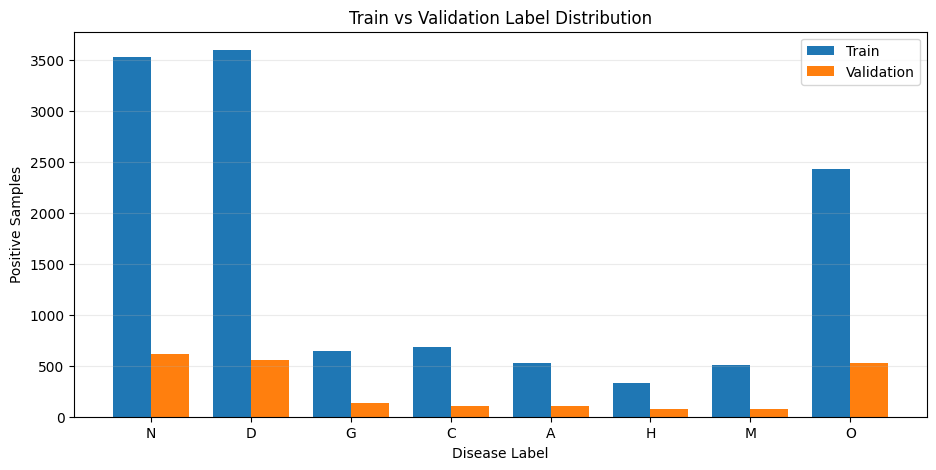

In [16]:
import matplotlib.pyplot as plt

train_label_counts = np.stack([s["label"] for s in train_samples]).sum(axis=0)
val_label_counts = np.stack([s["label"] for s in val_samples]).sum(axis=0)

x = np.arange(len(LABEL_COLS))
width = 0.38

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, train_label_counts, width=width, label="Train")
plt.bar(x + width/2, val_label_counts, width=width, label="Validation")
plt.xticks(x, LABEL_COLS)
plt.title("Train vs Validation Label Distribution")
plt.xlabel("Disease Label")
plt.ylabel("Positive Samples")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


In [81]:
from model import build_model
import torch.nn as nn
import torch

MODEL_NAME = "custom_cnn"
# options: "resnet18", "resnet50", "efficientnet_b0", "custom_cnn"

model = build_model(
    model_name=MODEL_NAME,
    num_labels=len(LABEL_COLS),
    dropout=0.45,
    pretrained=(MODEL_NAME != "custom_cnn")
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

print("Using model:", MODEL_NAME)
print(model.__class__.__name__)

Using model: custom_cnn
CustomCNN


In [82]:
@torch.no_grad()
def multilabel_accuracy_from_probs(probs, y, threshold=0.3):
    preds = (probs >= threshold).to(y.dtype)
    return (preds == y).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device ="cpu"):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits)
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += multilabel_accuracy_from_probs(probs, y) * bs
        n += bs

    return {
        "loss": total_loss / n,
        "acc": total_acc / n,
    }


@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device="cpu", threshold=0.5):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    all_probs = []
    all_targets = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()

        logits = model(x)
        loss = criterion(logits, y)
        probs = torch.sigmoid(logits)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += multilabel_accuracy_from_probs(probs, y, threshold=threshold) * bs
        n += bs

        all_probs.append(probs.cpu())
        all_targets.append(y.cpu())

    probs = torch.cat(all_probs).numpy()
    targets = torch.cat(all_targets).numpy().astype(int)
    preds = (probs >= threshold).astype(int)

    macro_f1 = f1_score(targets, preds, average="macro", zero_division=0)
    micro_f1 = f1_score(targets, preds, average="micro", zero_division=0)
    exact_match = (preds == targets).all(axis=1).mean()
    per_class_f1 = f1_score(targets, preds, average=None, zero_division=0)

    return {
        "loss": total_loss / n,
        "acc": total_acc / n,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "exact_match": exact_match,
        "per_class_f1": per_class_f1,
        "probs": probs,
        "preds": preds,
        "targets": targets,
    }
best_val_loss = float("inf")
best_epoch_loss = -1
best_state_loss = None

best_val_macro_f1 = -1.0
best_epoch_f1 = -1
best_state_f1 = None
best_metrics_f1 = None

history = []

EARLY_STOPPING_PATIENCE = 5
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    
    train_metrics = train_one_epoch(
        model, train_loader, criterion,
        optimizer=optimizer, device=DEVICE
    )

    # Evaluate model normally
    val_metrics = evaluate_epoch(
        model,
        val_loader,
        criterion,
        device=DEVICE,
        threshold=0.5
    )
    
    # Tune thresholds
    best_thresholds, tuned_per_class_f1 = tune_thresholds_per_class(
        val_metrics["probs"],
        val_metrics["targets"]
    )
    
    # Evaluate with tuned thresholds
    tuned_metrics = evaluate_with_thresholds(
        val_metrics["probs"],
        val_metrics["targets"],
        best_thresholds
    )

    scheduler.step(val_metrics["macro_f1"])
    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_micro_f1": val_metrics["micro_f1"],
        "val_exact_match": val_metrics["exact_match"],
        "lr": current_lr,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics['loss']:.4f} acc {train_metrics['acc']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} acc {val_metrics['acc']:.4f} | "
        f"macro_f1@0.5 {val_metrics['macro_f1']:.4f} | "
        f"macro_f1_tuned {tuned_metrics['macro_f1']:.4f} | "
        f"exact_tuned {tuned_metrics['exact_match']:.4f} | "
        f"lr {current_lr:.6f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch_loss = epoch
        best_state_loss = copy.deepcopy(model.state_dict())

    improved_f1 = (
        val_metrics["macro_f1"] > best_val_macro_f1
    ) or (
        np.isclose(val_metrics["macro_f1"], best_val_macro_f1) and
        val_metrics["loss"] < (best_metrics_f1["loss"] if best_metrics_f1 is not None else float("inf"))
    )

    if improved_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        best_epoch_f1 = epoch
        best_state_f1 = copy.deepcopy(model.state_dict())
        best_metrics_f1 = {
            "loss": val_metrics["loss"],
            "acc@0.5": val_metrics["acc"],
            "macro_f1@0.5": val_metrics["macro_f1"],
            "micro_f1@0.5": val_metrics["micro_f1"],
            "exact@0.5": val_metrics["exact_match"],
            "per_class_f1@0.5": val_metrics["per_class_f1"],
            "macro_f1_tuned": tuned_metrics["macro_f1"],
            "micro_f1_tuned": tuned_metrics["micro_f1"],
            "exact_tuned": tuned_metrics["exact_match"],
            "per_class_f1_tuned": tuned_metrics["per_class_f1"],
        }
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No macro F1 improvement for {epochs_no_improve} epoch(s)")

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(
            f"Early stopping triggered at epoch {epoch}. "
            f"Best macro F1: {best_val_macro_f1:.4f} at epoch {best_epoch_f1}."
        )
        break

Epoch 01 | train loss 1.1580 acc 0.1993 | val loss 1.1551 acc 0.5398 | macro_f1@0.5 0.2480 | macro_f1_tuned 0.3131 | exact_tuned 0.0000 | lr 0.000300
Epoch 02 | train loss 1.1189 acc 0.2454 | val loss 1.1155 acc 0.5958 | macro_f1@0.5 0.2626 | macro_f1_tuned 0.3355 | exact_tuned 0.0011 | lr 0.000300
Epoch 03 | train loss 1.0827 acc 0.2784 | val loss 1.0917 acc 0.6487 | macro_f1@0.5 0.2877 | macro_f1_tuned 0.3713 | exact_tuned 0.0000 | lr 0.000300
Epoch 04 | train loss 1.0532 acc 0.3103 | val loss 1.0494 acc 0.6359 | macro_f1@0.5 0.3393 | macro_f1_tuned 0.3952 | exact_tuned 0.0011 | lr 0.000300
Epoch 05 | train loss 1.0260 acc 0.3371 | val loss 1.0497 acc 0.6628 | macro_f1@0.5 0.3207 | macro_f1_tuned 0.4017 | exact_tuned 0.0130 | lr 0.000300
No macro F1 improvement for 1 epoch(s)
Epoch 06 | train loss 1.0174 acc 0.3537 | val loss 1.0639 acc 0.6669 | macro_f1@0.5 0.3527 | macro_f1_tuned 0.4076 | exact_tuned 0.0049 | lr 0.000300
Epoch 07 | train loss 1.0045 acc 0.3609 | val loss 1.0586 acc

In [83]:
probs   = val_metrics["probs"]
targets = val_metrics["targets"]

from thresholds import tune_thresholds_per_class
best_thresholds, _ = tune_thresholds_per_class(probs, targets)

In [84]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_multilabel_confusion_matrices(targets, preds, class_names=None):
    num_classes = targets.shape[1]

    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]

    cols = 4
    rows = int(np.ceil(num_classes / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()

    for i in range(num_classes):
        cm = confusion_matrix(targets[:, i], preds[:, i])

        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=axes[i], colorbar=False)

        axes[i].set_title(class_names[i])

    for j in range(num_classes, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [85]:
checkpoint_dir = "/kaggle/working/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

best_model_f1_path = os.path.join(checkpoint_dir, f"{MODEL_NAME}_odir_multilabel_best_f1.pt")
best_model_loss_path = os.path.join(checkpoint_dir, f"{MODEL_NAME}_odir_multilabel_best_loss.pt")
last_model_path = os.path.join(checkpoint_dir, f"{MODEL_NAME}_odir_multilabel_last.pt")
history_path = os.path.join(checkpoint_dir, f"{MODEL_NAME}_training_history.csv")

if best_state_f1 is not None:
    torch.save(best_state_f1, best_model_f1_path)
if best_state_loss is not None:
    torch.save(best_state_loss, best_model_loss_path)
torch.save(model.state_dict(), last_model_path)
pd.DataFrame(history).to_csv(history_path, index=False)

print(f"Best epoch by tuned macro F1: {best_epoch_f1}")
if best_metrics_f1 is not None:
    print(f"Best val macro F1 @0.5: {best_metrics_f1['macro_f1@0.5']:.4f}")
    print(f"Best val macro F1 tuned: {best_metrics_f1['macro_f1_tuned']:.4f}")
    print(f"Val loss at best F1 epoch: {best_metrics_f1['loss']:.4f}")
    print(f"Val acc at best F1 epoch @0.5: {best_metrics_f1['acc@0.5']:.4f}")
    print(f"Val exact match at best F1 epoch @0.5: {best_metrics_f1['exact@0.5']:.4f}")
    print(f"Val exact match at best F1 epoch tuned: {best_metrics_f1['exact_tuned']:.4f}")

print(f"Best epoch by val loss: {best_epoch_loss}")
print(f"Best val loss: {best_val_loss:.4f}")
print("Saved best F1 model to:", best_model_f1_path)
print("Saved best loss model to:", best_model_loss_path)
print("Saved last model to:", last_model_path)
print("Saved history to:", history_path)

Best epoch by tuned macro F1: 19
Best val macro F1 @0.5: 0.4018
Best val macro F1 tuned: 0.4416
Val loss at best F1 epoch: 1.0132
Val acc at best F1 epoch @0.5: 0.6785
Val exact match at best F1 epoch @0.5: 0.0184
Val exact match at best F1 epoch tuned: 0.0054
Best epoch by val loss: 24
Best val loss: 0.9740
Saved best F1 model to: /kaggle/working/checkpoints/custom_cnn_odir_multilabel_best_f1.pt
Saved best loss model to: /kaggle/working/checkpoints/custom_cnn_odir_multilabel_best_loss.pt
Saved last model to: /kaggle/working/checkpoints/custom_cnn_odir_multilabel_last.pt
Saved history to: /kaggle/working/checkpoints/custom_cnn_training_history.csv


In [86]:
# ── Results Collection ─────────────────────────────────────────────────────────
# Run this after each model to build up the comparison table

if "all_results" not in dir():
    all_results = {}

all_results[MODEL_NAME] = {
    "macro_f1@0.5":      best_metrics_f1["macro_f1@0.5"],
    "macro_f1_tuned":    best_metrics_f1["macro_f1_tuned"],
    "micro_f1@0.5":      best_metrics_f1["micro_f1@0.5"],
    "exact_match@0.5":   best_metrics_f1["exact@0.5"],
    "exact_match_tuned": best_metrics_f1["exact_tuned"],
    "macro_roc_auc":     macro_auc,
    "macro_avg_prec":    macro_ap,
    "best_epoch":        best_epoch_f1,
    "val_loss":          best_metrics_f1["loss"],
}

print(f"Saved results for {MODEL_NAME}")
print(pd.DataFrame(all_results).T.to_string())

Saved results for custom_cnn
                 macro_f1@0.5  macro_f1_tuned  micro_f1@0.5  exact_match@0.5  exact_match_tuned  macro_roc_auc  macro_avg_prec  best_epoch  val_loss
efficientnet_b0      0.541954        0.566934      0.535572         0.339816           0.319287       0.812273        0.545234        27.0  2.057226
resnet18             0.462996        0.525569      0.476845         0.143166           0.057807       0.812273        0.545234         5.0  1.034480
resnet50             0.495424        0.581255      0.495435         0.179363           0.279308       0.772023        0.489654         5.0  0.874371
custom_cnn           0.401753        0.441555      0.400000         0.018368           0.005402       0.811187        0.565426        19.0  1.013151


In [87]:
# ── Save eval data for this model ─────────────────────────────────────────────
import pickle

eval_save = {
    "probs":             val_metrics["probs"],
    "targets":           val_metrics["targets"],
    "preds":             val_metrics["preds"],
    "roc_aucs":          roc_aucs,
    "avg_precs":         avg_precs,
    "macro_auc":         macro_auc,
    "macro_ap":          macro_ap,
    "best_metrics_f1":   best_metrics_f1,
    "history":           history,
    "best_epoch_f1":     best_epoch_f1,
    "best_epoch_loss":   best_epoch_loss,
    "MODEL_NAME":        MODEL_NAME,
}

save_path = f"/kaggle/working/checkpoints/{MODEL_NAME}_eval_data.pkl"
with open(save_path, "wb") as f:
    pickle.dump(eval_save, f)

print(f"Saved: {save_path}")

Saved: /kaggle/working/checkpoints/custom_cnn_eval_data.pkl


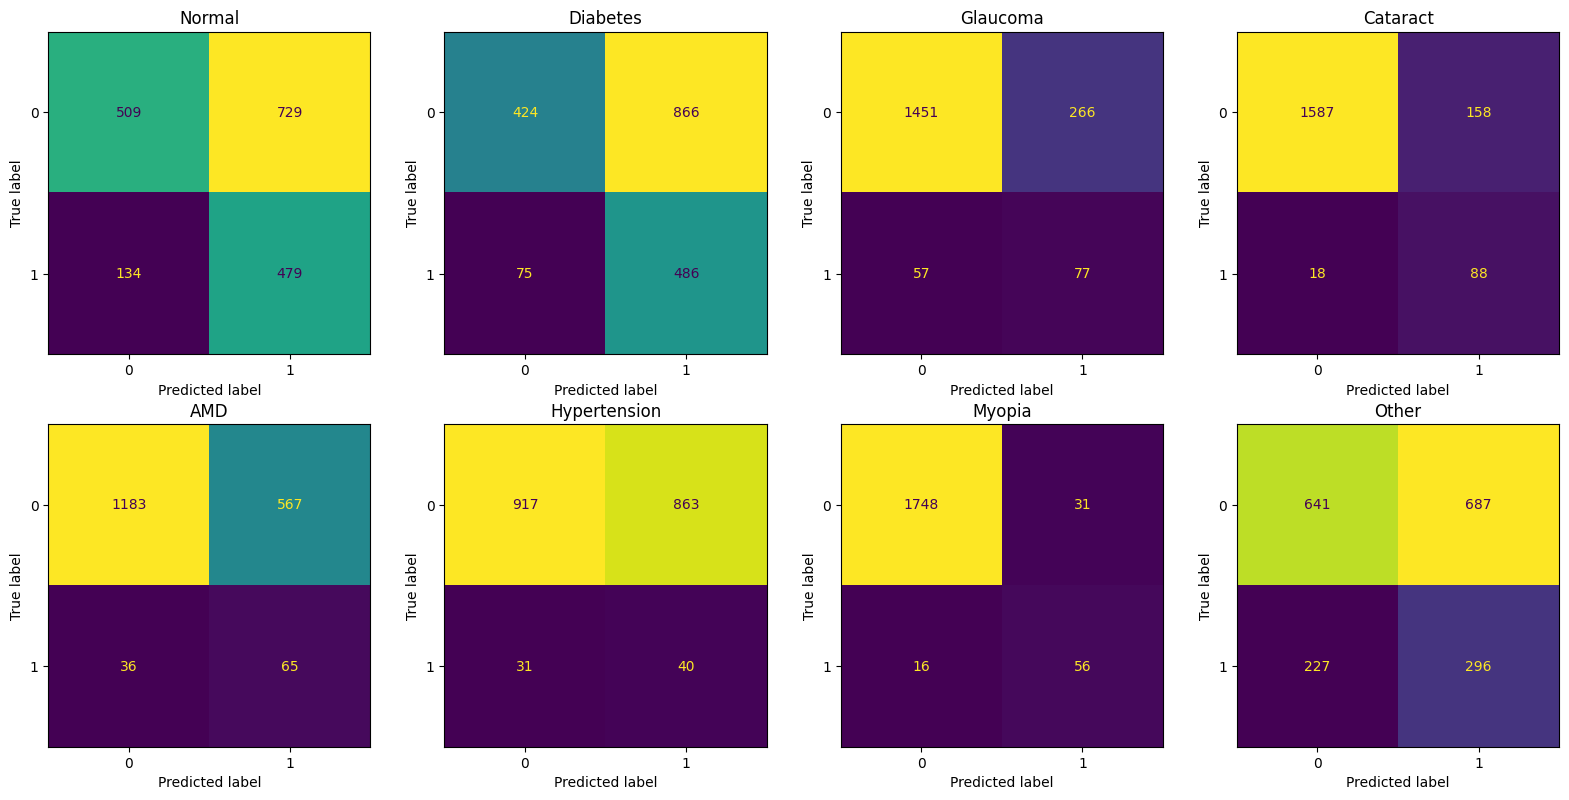

In [88]:
model.load_state_dict(best_state_f1)

val_metrics = evaluate_epoch(
    model, val_loader, criterion,
    device=DEVICE, threshold=0.5
)

plot_multilabel_confusion_matrices(
    val_metrics["targets"],
    val_metrics["preds"],
    class_names=["Normal", "Diabetes", "Glaucoma", "Cataract", "AMD", "Hypertension", "Myopia", "Other"]  # adjust
)

In [89]:
# ── Classification Report ──────────────────────────────────────────────────────
from sklearn.metrics import classification_report

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract", "AMD", "Hypertension", "Myopia", "Other"]

# At 0.5 threshold
print("📋 Classification Report (threshold = 0.5):")
print(classification_report(
    targets,
    (probs >= 0.5).astype(int),
    target_names=CLASS_NAMES,
    zero_division=0
))

# At tuned thresholds
print("📋 Classification Report (tuned thresholds):")
print(classification_report(
    targets,
    (probs >= best_thresholds).astype(int),
    target_names=CLASS_NAMES,
    zero_division=0
))

📋 Classification Report (threshold = 0.5):
              precision    recall  f1-score   support

      Normal       0.41      0.79      0.54       613
    Diabetes       0.39      0.71      0.50       561
    Glaucoma       0.19      0.75      0.30       134
    Cataract       0.32      0.91      0.48       106
         AMD       0.12      0.68      0.20       101
Hypertension       0.05      0.54      0.10        71
      Myopia       0.45      0.81      0.57        72
       Other       0.30      0.54      0.39       523

   micro avg       0.28      0.70      0.40      2181
   macro avg       0.28      0.71      0.39      2181
weighted avg       0.34      0.70      0.45      2181
 samples avg       0.30      0.72      0.41      2181

📋 Classification Report (tuned thresholds):
              precision    recall  f1-score   support

      Normal       0.39      0.91      0.55       613
    Diabetes       0.38      0.84      0.52       561
    Glaucoma       0.52      0.25      0.34  


Class             ROC-AUC  Avg Precision
------------------------------------------
Normal             0.6368         0.4518
Diabetes           0.6507         0.4133
Glaucoma           0.8072         0.2758
Cataract           0.9485         0.7331
AMD                0.7529         0.1437
Hypertension       0.5921         0.0574
Myopia             0.9146         0.7076
Other              0.5385         0.3293
------------------------------------------
Macro Average      0.7302         0.3890


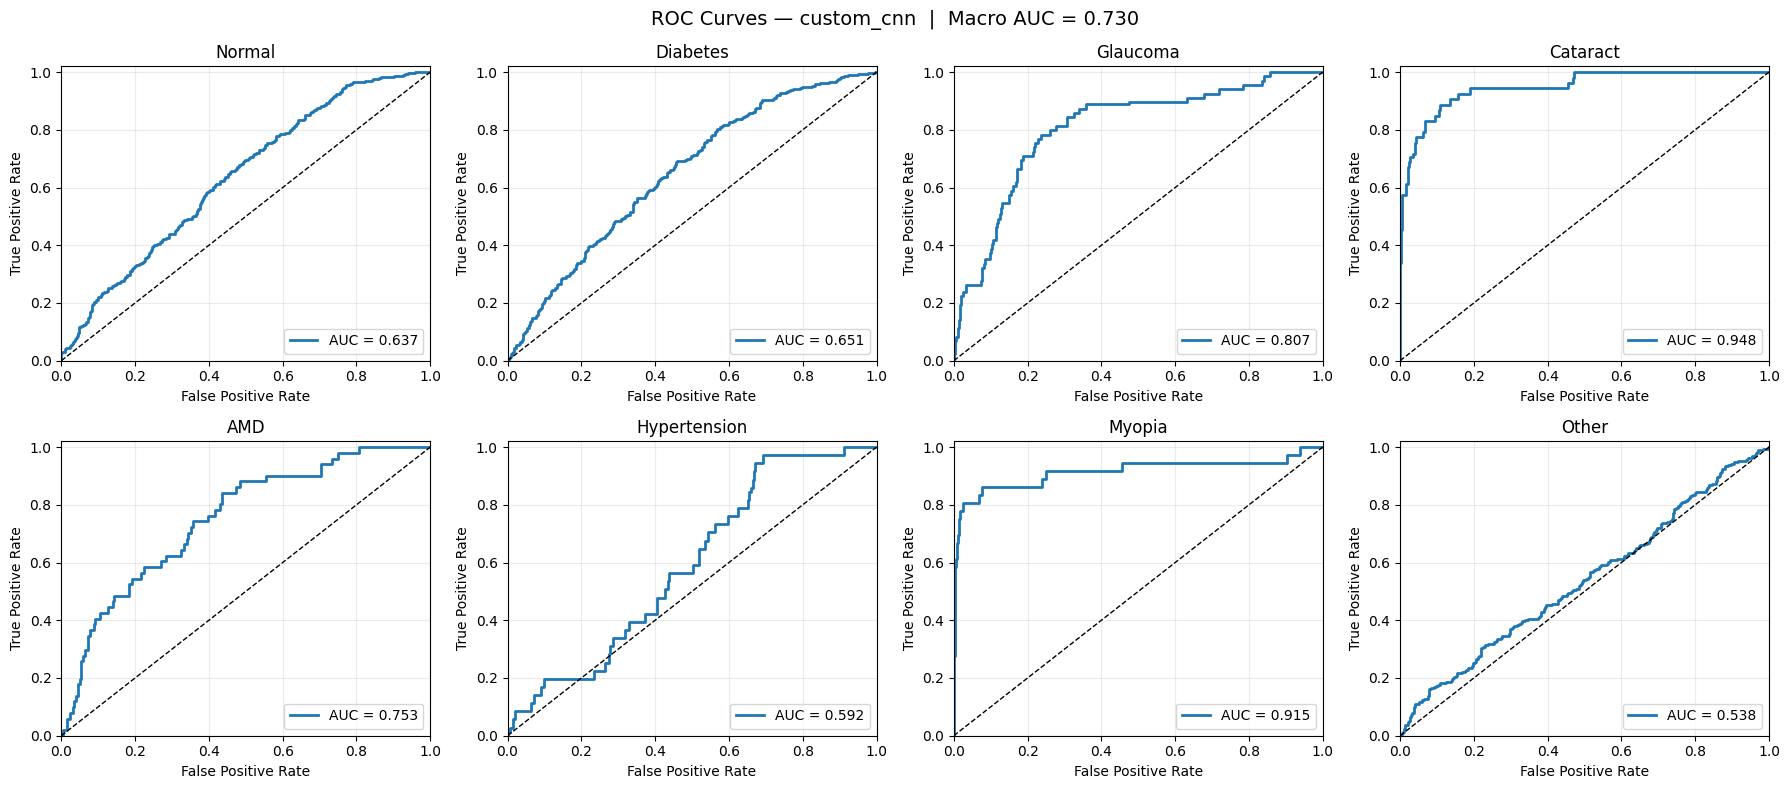

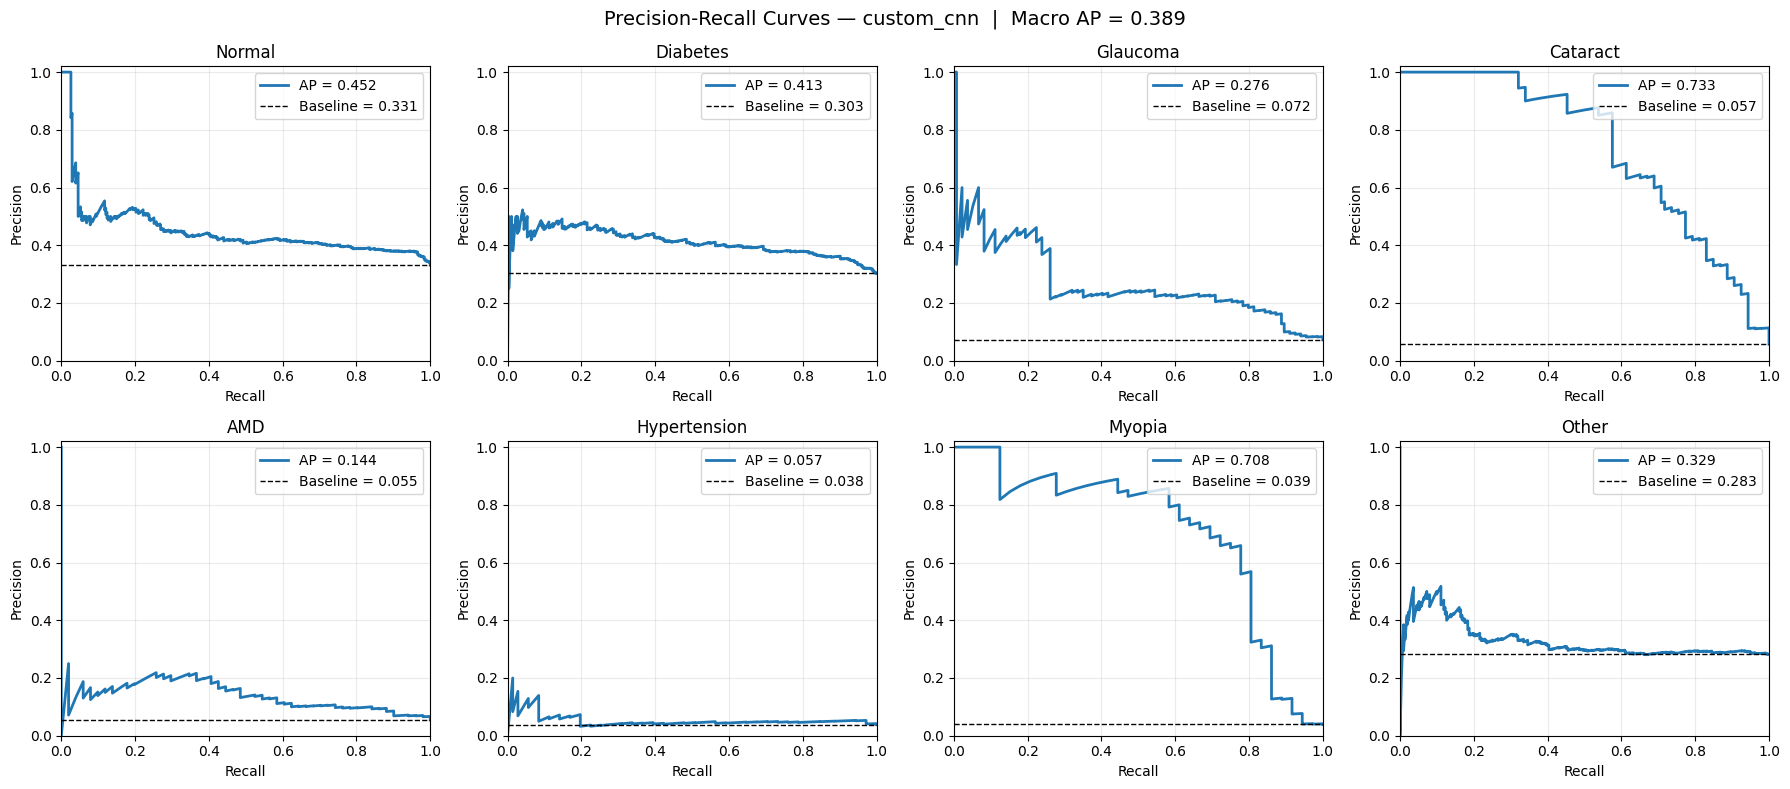

In [90]:
# ── ROC-AUC & Precision-Recall Curves ─────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve
)

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract", "AMD", "Hypertension", "Myopia", "Other"]

probs   = val_metrics["probs"]    # shape (N, 8)  – float
targets = val_metrics["targets"]  # shape (N, 8)  – int

# ── Per-class scores ───────────────────────────────────────────────────────────
roc_aucs = []
avg_precs = []

for i, name in enumerate(CLASS_NAMES):
    # Skip classes with only one label present (can't compute AUC)
    if len(np.unique(targets[:, i])) < 2:
        print(f"[WARNING] {name}: only one class present – AUC skipped")
        roc_aucs.append(float("nan"))
        avg_precs.append(float("nan"))
        continue
    roc_aucs.append(roc_auc_score(targets[:, i], probs[:, i]))
    avg_precs.append(average_precision_score(targets[:, i], probs[:, i]))

macro_auc = np.nanmean(roc_aucs)
macro_ap  = np.nanmean(avg_precs)

# ── Summary table ──────────────────────────────────────────────────────────────
print(f"\n{'Class':<16} {'ROC-AUC':>8} {'Avg Precision':>14}")
print("-" * 42)
for name, auc, ap in zip(CLASS_NAMES, roc_aucs, avg_precs):
    print(f"{name:<16} {auc:>8.4f} {ap:>14.4f}")
print("-" * 42)
print(f"{'Macro Average':<16} {macro_auc:>8.4f} {macro_ap:>14.4f}")

# ── ROC Curves ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (name, auc) in enumerate(zip(CLASS_NAMES, roc_aucs)):
    ax = axes[i]
    if np.isnan(auc):
        ax.set_title(f"{name}\n(skipped)")
        ax.axis("off")
        continue

    fpr, tpr, _ = roc_curve(targets[:, i], probs[:, i])
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(name)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.25)

plt.suptitle(f"ROC Curves — {MODEL_NAME}  |  Macro AUC = {macro_auc:.3f}", fontsize=14)
plt.tight_layout()
plt.show()

# ── Precision-Recall Curves ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (name, ap) in enumerate(zip(CLASS_NAMES, avg_precs)):
    ax = axes[i]
    if np.isnan(ap):
        ax.set_title(f"{name}\n(skipped)")
        ax.axis("off")
        continue

    prec, rec, _ = precision_recall_curve(targets[:, i], probs[:, i])
    baseline = targets[:, i].mean()          # positive rate = random classifier baseline
    ax.plot(rec, prec, lw=2, label=f"AP = {ap:.3f}")
    ax.axhline(baseline, color="k", linestyle="--", lw=1, label=f"Baseline = {baseline:.3f}")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(name)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.25)

plt.suptitle(f"Precision-Recall Curves — {MODEL_NAME}  |  Macro AP = {macro_ap:.3f}", fontsize=14)
plt.tight_layout()
plt.show()

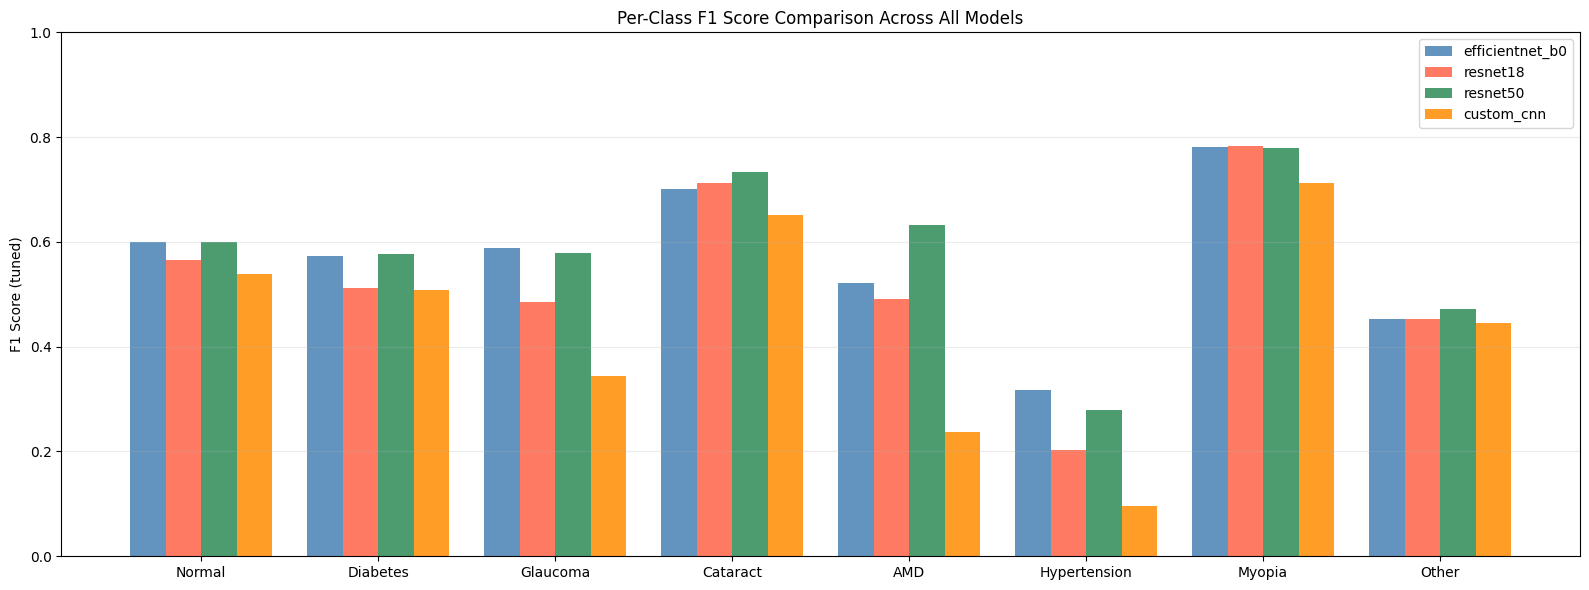

In [91]:
# ── Per-class F1 comparison across all 4 models ───────────────────────────────
import pickle

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract", "AMD", "Hypertension", "Myopia", "Other"]
MODEL_NAMES = ["efficientnet_b0", "resnet18", "resnet50", "custom_cnn"]
colors      = ["steelblue", "tomato", "seagreen", "darkorange"]

per_class_f1_all = {}

for name in MODEL_NAMES:
    path = f"/kaggle/working/checkpoints/{name}_eval_data.pkl"
    try:
        with open(path, "rb") as f:
            data = pickle.load(f)
        per_class_f1_all[name] = data["best_metrics_f1"]["per_class_f1_tuned"]
    except FileNotFoundError:
        print(f"Missing {name}")

x     = np.arange(len(CLASS_NAMES))
width = 0.2
fig, ax = plt.subplots(figsize=(16, 6))

for i, (name, color) in enumerate(zip(MODEL_NAMES, colors)):
    if name in per_class_f1_all:
        ax.bar(x + i * width, per_class_f1_all[name], width,
               label=name, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel("F1 Score (tuned)")
ax.set_title("Per-Class F1 Score Comparison Across All Models")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("/kaggle/working/per_class_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

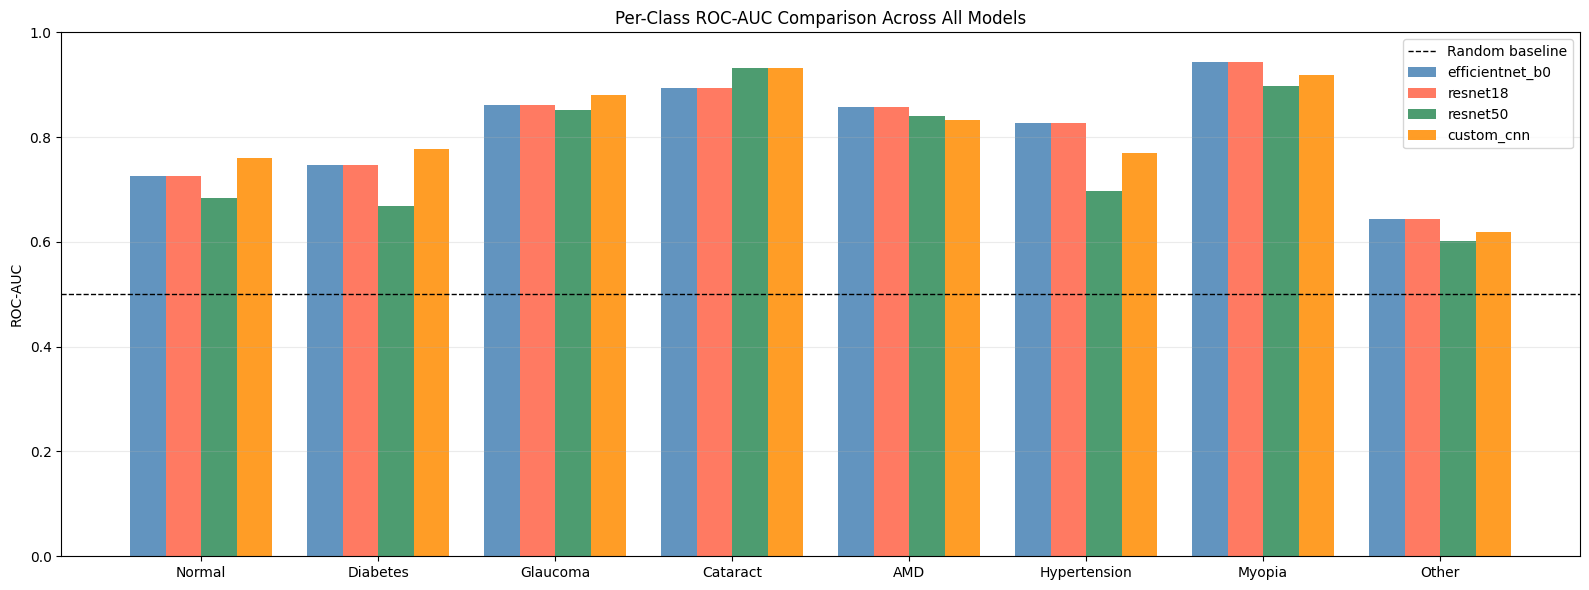

In [92]:
# ── Per-class ROC-AUC comparison across all 4 models ──────────────────────────
per_class_auc_all = {}

for name in MODEL_NAMES:
    path = f"/kaggle/working/checkpoints/{name}_eval_data.pkl"
    try:
        with open(path, "rb") as f:
            data = pickle.load(f)
        per_class_auc_all[name] = data["roc_aucs"]
    except FileNotFoundError:
        print(f"Missing {name}")

fig, ax = plt.subplots(figsize=(16, 6))

for i, (name, color) in enumerate(zip(MODEL_NAMES, colors)):
    if name in per_class_auc_all:
        ax.bar(x + i * width, per_class_auc_all[name], width,
               label=name, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel("ROC-AUC")
ax.set_title("Per-Class ROC-AUC Comparison Across All Models")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="k", linestyle="--", lw=1, label="Random baseline")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("/kaggle/working/per_class_auc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

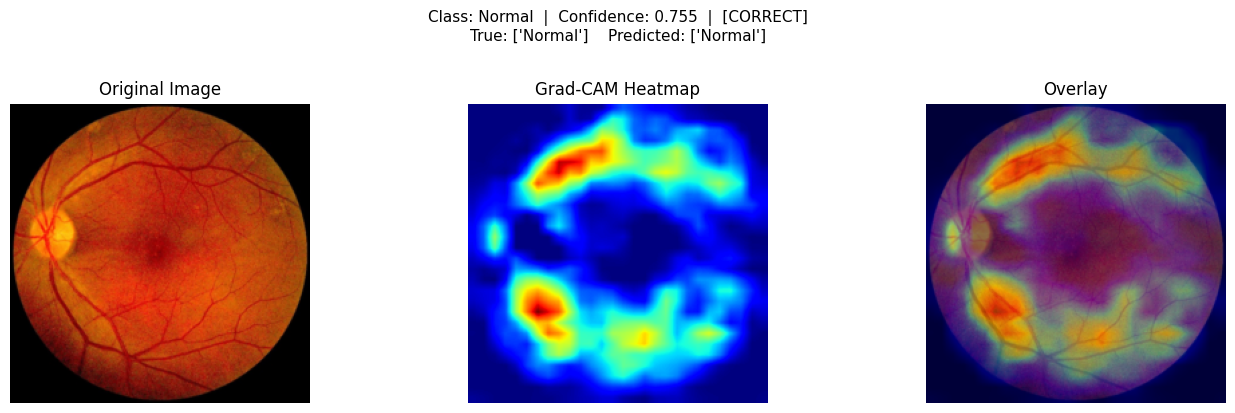

Saved: gradcam_normal.png

Probabilities for this image:
          Normal: 0.7554  ███████████████
        Diabetes: 0.3874  ███████
        Glaucoma: 0.0984  █
        Cataract: 0.0356  
             AMD: 0.4505  █████████
    Hypertension: 0.1294  ██
          Myopia: 0.0138  
           Other: 0.2017  ████



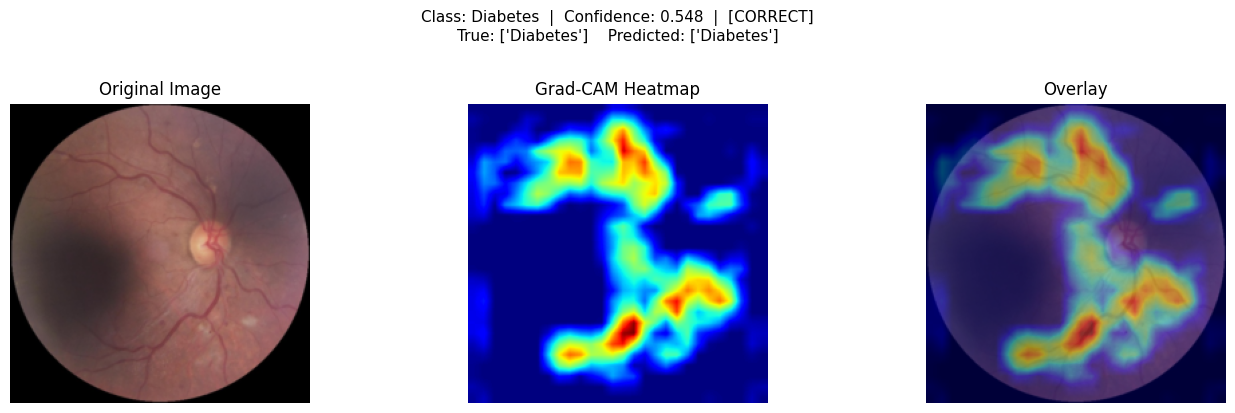

Saved: gradcam_diabetes.png

Probabilities for this image:
          Normal: 0.4932  █████████
        Diabetes: 0.5483  ██████████
        Glaucoma: 0.2149  ████
        Cataract: 0.3608  ███████
             AMD: 0.3316  ██████
    Hypertension: 0.4794  █████████
          Myopia: 0.0123  
           Other: 0.4634  █████████



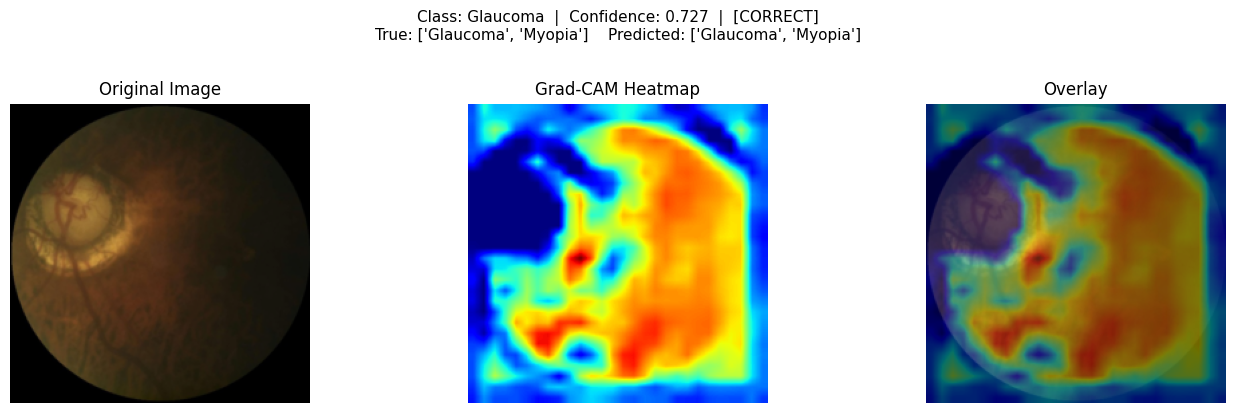

Saved: gradcam_glaucoma.png

Probabilities for this image:
          Normal: 0.4625  █████████
        Diabetes: 0.4144  ████████
        Glaucoma: 0.7275  ██████████████
        Cataract: 0.1588  ███
             AMD: 0.4881  █████████
    Hypertension: 0.3327  ██████
          Myopia: 0.5695  ███████████
           Other: 0.4762  █████████



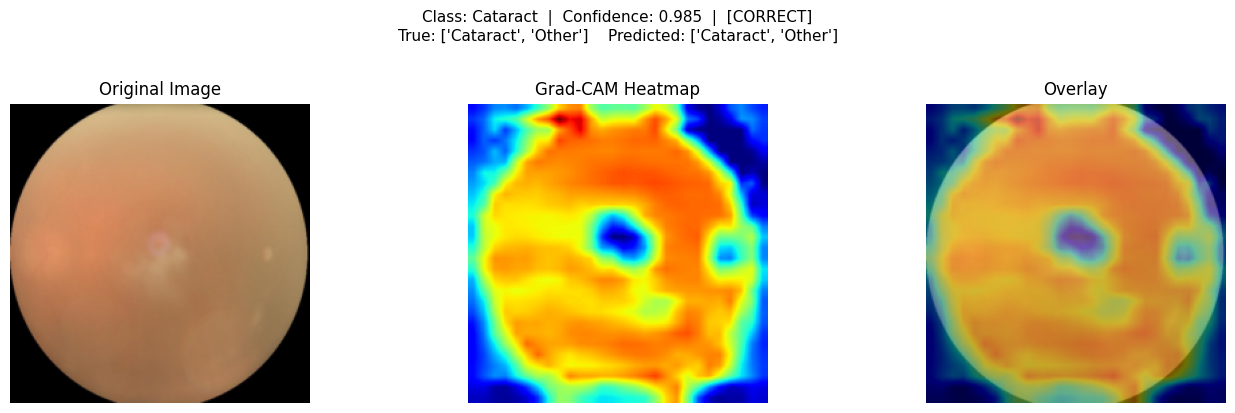

Saved: gradcam_cataract.png

Probabilities for this image:
          Normal: 0.3282  ██████
        Diabetes: 0.3202  ██████
        Glaucoma: 0.4926  █████████
        Cataract: 0.9848  ███████████████████
             AMD: 0.2879  █████
    Hypertension: 0.2493  ████
          Myopia: 0.0250  
           Other: 0.5535  ███████████

[AMD] No fully correct example found — using most confident instead


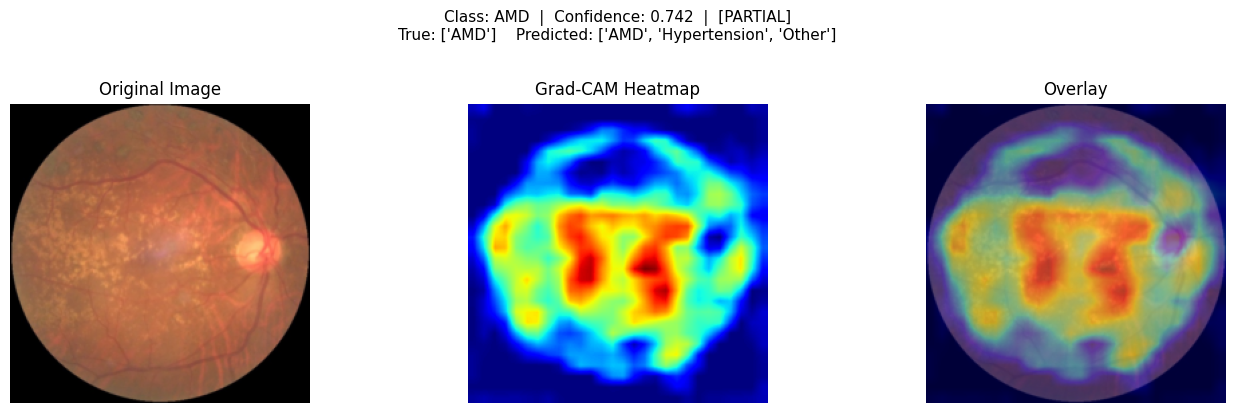

Saved: gradcam_amd.png

Probabilities for this image:
          Normal: 0.4383  ████████
        Diabetes: 0.4961  █████████
        Glaucoma: 0.4684  █████████
        Cataract: 0.0819  █
             AMD: 0.7419  ██████████████
    Hypertension: 0.5259  ██████████
          Myopia: 0.4214  ████████
           Other: 0.5558  ███████████

[Hypertension] No fully correct example found — using most confident instead


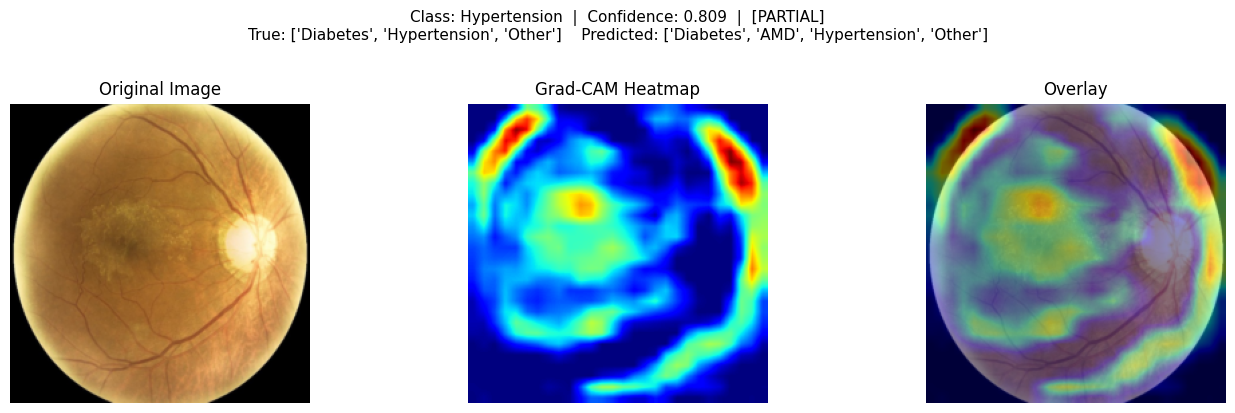

Saved: gradcam_hypertension.png

Probabilities for this image:
          Normal: 0.3876  ███████
        Diabetes: 0.7777  ███████████████
        Glaucoma: 0.0480  
        Cataract: 0.0273  
             AMD: 0.5389  ██████████
    Hypertension: 0.8090  ████████████████
          Myopia: 0.0034  
           Other: 0.5647  ███████████



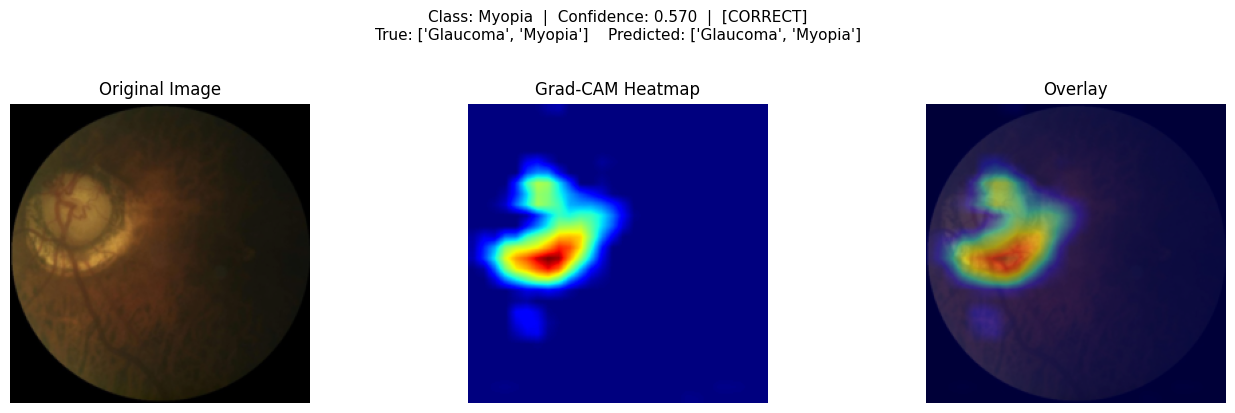

Saved: gradcam_myopia.png

Probabilities for this image:
          Normal: 0.4625  █████████
        Diabetes: 0.4144  ████████
        Glaucoma: 0.7275  ██████████████
        Cataract: 0.1588  ███
             AMD: 0.4881  █████████
    Hypertension: 0.3327  ██████
          Myopia: 0.5695  ███████████
           Other: 0.4762  █████████



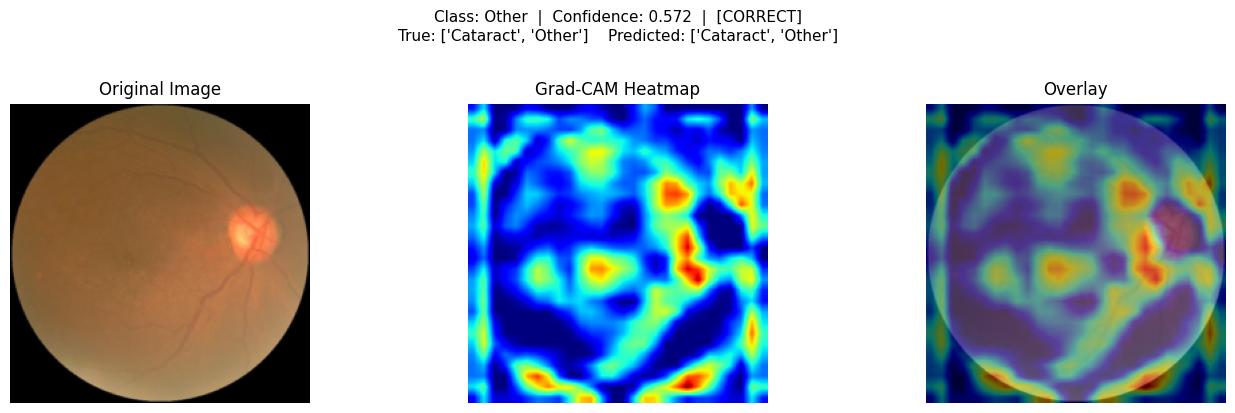

Saved: gradcam_other.png

Probabilities for this image:
          Normal: 0.4698  █████████
        Diabetes: 0.4654  █████████
        Glaucoma: 0.4581  █████████
        Cataract: 0.7676  ███████████████
             AMD: 0.4117  ████████
    Hypertension: 0.4479  ████████
          Myopia: 0.0138  
           Other: 0.5722  ███████████

[AMD] No fully correct example found — using most confident instead
[Hypertension] No fully correct example found — using most confident instead


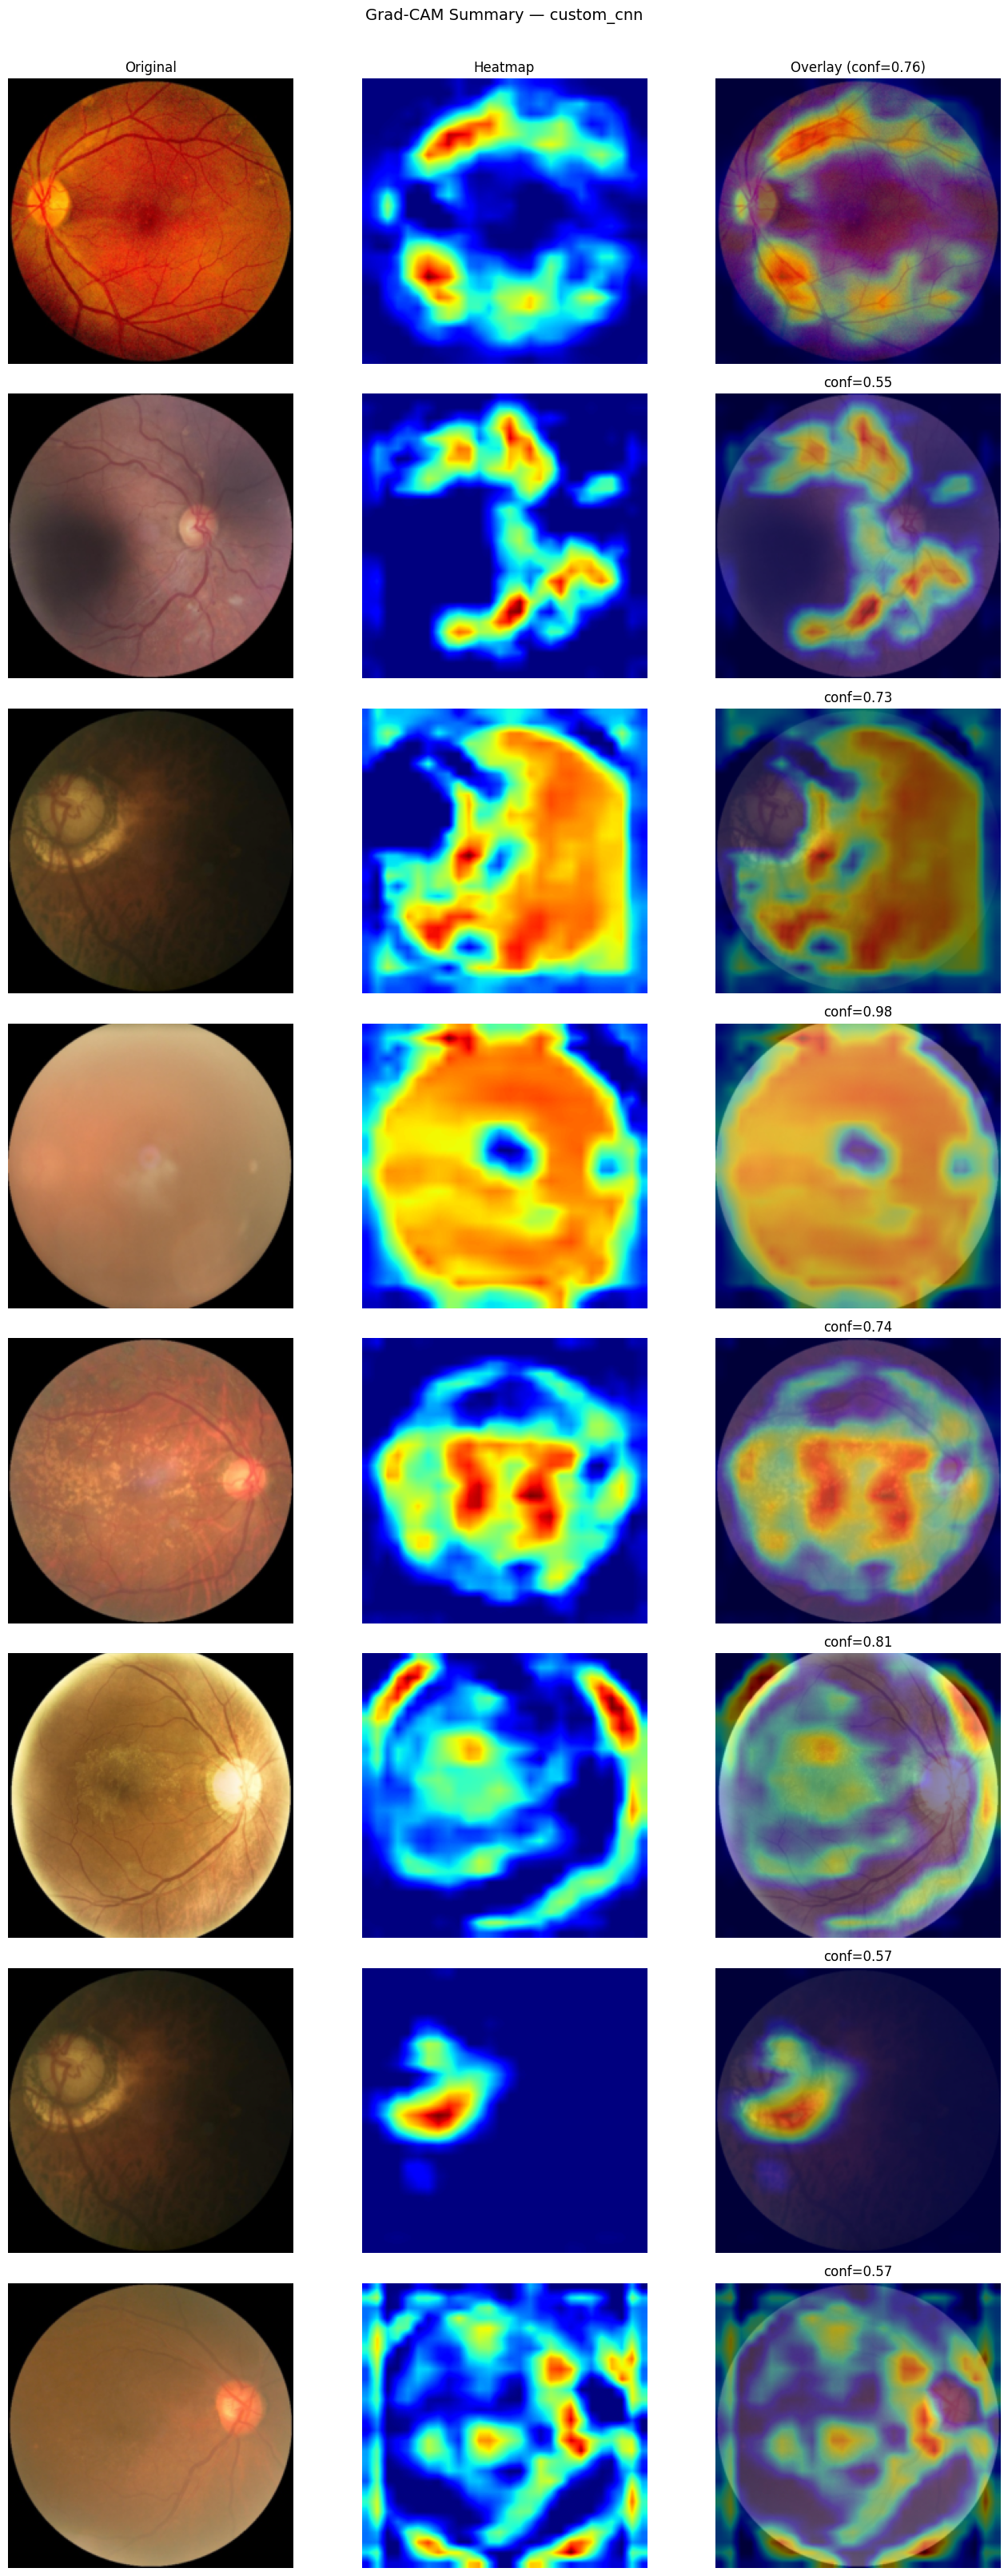

Saved: gradcam_summary_grid.png


In [97]:
# ── Grad-CAM Analysis ──────────────────────────────────────────────────────────
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract", "AMD", "Hypertension", "Myopia", "Other"]
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def unnormalize_image(tensor):
    img = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)

# ── Disable inplace ReLU for Grad-CAM compatibility ───────────────────────────
def disable_inplace_relu(model):
    for module in model.modules():
        if isinstance(module, torch.nn.ReLU):
            module.inplace = False

disable_inplace_relu(model)

# ── Grad-CAM class ─────────────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(x)
        logits[0, class_idx].backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam[0, 0].detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        probs = torch.sigmoid(logits).detach().cpu().numpy()[0]
        return cam, probs

if MODEL_NAME == "efficientnet_b0":
    target_layer = model.features[-1]
elif MODEL_NAME == "resnet18":
    target_layer = model.layer4[-1]
elif MODEL_NAME == "resnet50":
    target_layer = model.layer4[-1]
elif MODEL_NAME == "custom_cnn":
    target_layer = model.features[-2]
else:
    raise ValueError(f"Unknown model: {MODEL_NAME}")

grad_cam = GradCAM(model, target_layer)

# ── Find best example where ALL labels are correctly predicted ─────────────────
def find_best_example(class_idx, threshold=0.5):
    best_idx  = None
    best_prob = 0.0

    for i, sample in enumerate(val_samples):
        # Must be a true positive for the target class
        if sample["label"][class_idx] != 1:
            continue

        pil_img = Image.open(sample["path"]).convert("RGB")
        x = val_tfm(pil_img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            probs_i = torch.sigmoid(model(x))[0].cpu().numpy()

        # Check ALL labels are predicted correctly
        true_labels = np.array(sample["label"])
        pred_labels = (probs_i >= threshold).astype(int)
        all_correct = np.array_equal(true_labels, pred_labels)

        if all_correct and probs_i[class_idx] > best_prob:
            best_prob = probs_i[class_idx]
            best_idx  = i

    # Fallback — if no fully correct example found, just find most confident
    if best_idx is None:
        print(f"[{CLASS_NAMES[class_idx]}] No fully correct example found — using most confident instead")
        for i, sample in enumerate(val_samples):
            if sample["label"][class_idx] != 1:
                continue
            pil_img = Image.open(sample["path"]).convert("RGB")
            x = val_tfm(pil_img).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                p = torch.sigmoid(model(x))[0, class_idx].item()
            if p > best_prob:
                best_prob = p
                best_idx  = i

    return best_idx, best_prob

# ── Plot one class ─────────────────────────────────────────────────────────────
def plot_gradcam_for_class(class_idx, threshold=0.5):
    sample_idx, confidence = find_best_example(class_idx, threshold)

    if sample_idx is None:
        print(f"No positive example found for {CLASS_NAMES[class_idx]}")
        return

    sample     = val_samples[sample_idx]
    pil_img    = Image.open(sample["path"]).convert("RGB")
    x          = val_tfm(pil_img).unsqueeze(0).to(DEVICE)
    cam, probs = grad_cam.generate(x, class_idx)
    img_np     = unnormalize_image(x[0])

    true_labels   = [CLASS_NAMES[i] for i, v in enumerate(sample["label"]) if v == 1]
    pred_labels   = [CLASS_NAMES[i] for i, p in enumerate(probs) if p >= threshold]
    fully_correct = sorted(true_labels) == sorted(pred_labels)

    # ✅ fig must be created BEFORE suptitle
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    fig.suptitle(
        f"Class: {CLASS_NAMES[class_idx]}  |  Confidence: {confidence:.3f}  |  "
        f"{'[CORRECT]' if fully_correct else '[PARTIAL]'}\n"
        f"True: {true_labels}    Predicted: {pred_labels}",
        fontsize=11, y=1.02
    )

    axes[0].imshow(img_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(cam, cmap="jet")
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    axes[2].imshow(img_np)
    axes[2].imshow(cam, cmap="jet", alpha=0.45)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig(f"/kaggle/working/gradcam_{CLASS_NAMES[class_idx].lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: gradcam_{CLASS_NAMES[class_idx].lower()}.png")

    print(f"\nProbabilities for this image:")
    for i, p in enumerate(probs):
        bar = "█" * int(p * 20)
        print(f"  {CLASS_NAMES[i]:>14}: {p:.4f}  {bar}")
    print()

# ── Summary grid — all 8 classes in one figure ────────────────────────────────
def plot_gradcam_summary_grid():
    fig, axes = plt.subplots(8, 3, figsize=(14, 32))
    fig.suptitle(f"Grad-CAM Summary — {MODEL_NAME}", fontsize=14, y=1.005)

    for class_idx, name in enumerate(CLASS_NAMES):
        sample_idx, confidence = find_best_example(class_idx)

        if sample_idx is None:
            for ax in axes[class_idx]:
                ax.axis("off")
                ax.set_title(f"{name} — no example found")
            continue

        sample     = val_samples[sample_idx]
        pil_img    = Image.open(sample["path"]).convert("RGB")
        x          = val_tfm(pil_img).unsqueeze(0).to(DEVICE)
        cam, probs = grad_cam.generate(x, class_idx)
        img_np     = unnormalize_image(x[0])

        axes[class_idx][0].imshow(img_np)
        axes[class_idx][0].set_ylabel(name, fontsize=11, rotation=0,
                                       labelpad=60, va="center")
        axes[class_idx][0].set_title("Original" if class_idx == 0 else "")
        axes[class_idx][0].axis("off")

        axes[class_idx][1].imshow(cam, cmap="jet")
        axes[class_idx][1].set_title("Heatmap" if class_idx == 0 else "")
        axes[class_idx][1].axis("off")

        axes[class_idx][2].imshow(img_np)
        axes[class_idx][2].imshow(cam, cmap="jet", alpha=0.45)
        axes[class_idx][2].set_title(f"Overlay (conf={confidence:.2f})" if class_idx == 0 else f"conf={confidence:.2f}")
        axes[class_idx][2].axis("off")

    plt.tight_layout()
    plt.savefig("/kaggle/working/gradcam_summary_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: gradcam_summary_grid.png")

# ── RUN ────────────────────────────────────────────────────────────────────────
# Option 1: Individual plot per class (clean, dissertation-ready)
for class_idx in range(len(CLASS_NAMES)):
    plot_gradcam_for_class(class_idx)

# Option 2: All 8 classes in one summary grid
plot_gradcam_summary_grid()

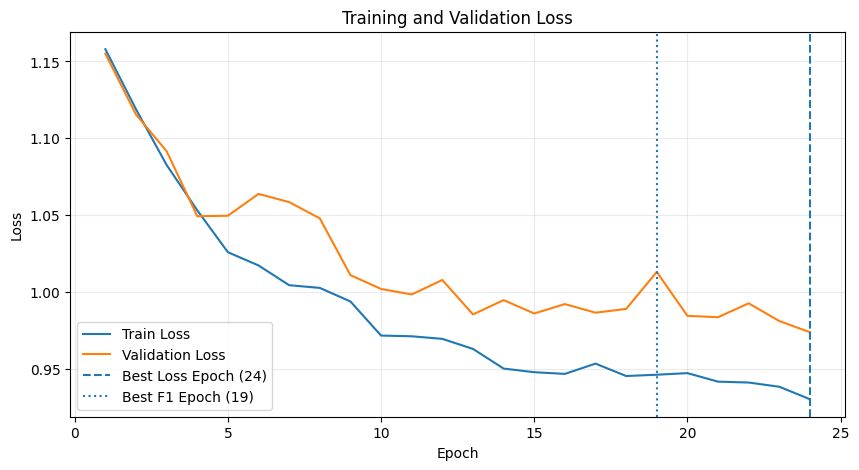

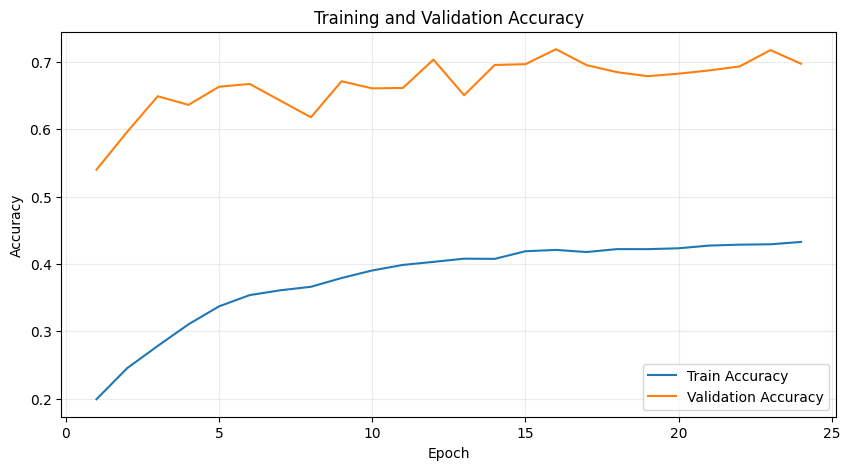

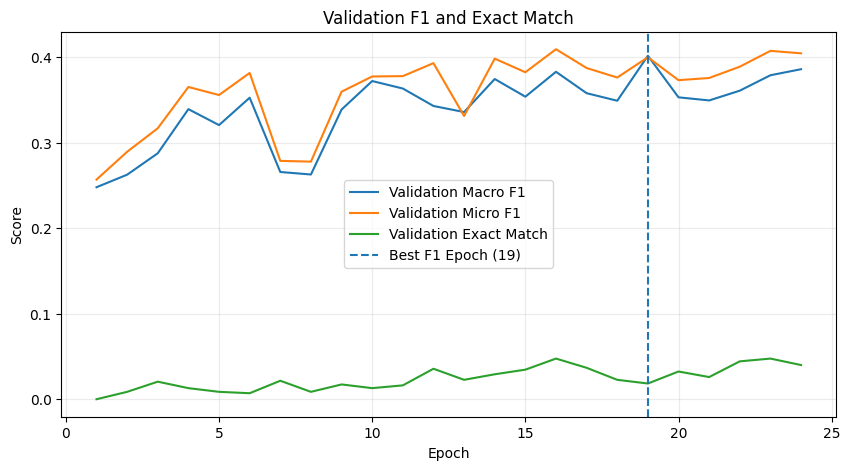

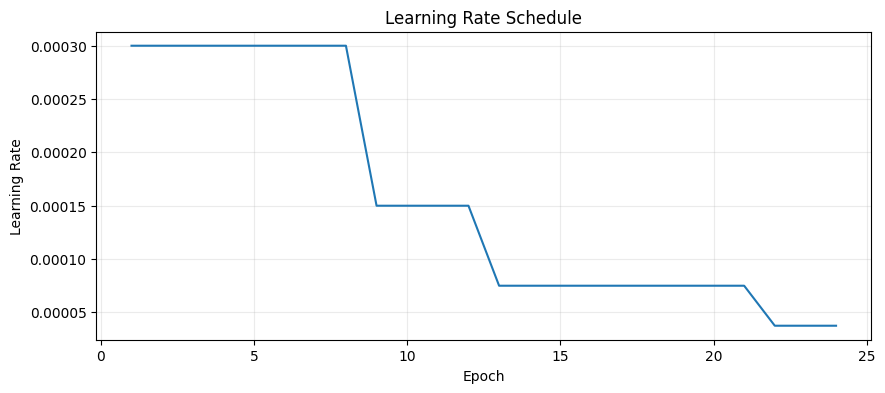

In [94]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.axvline(best_epoch_loss, linestyle="--", label=f"Best Loss Epoch ({best_epoch_loss})")
plt.axvline(best_epoch_f1, linestyle=":", label=f"Best F1 Epoch ({best_epoch_f1})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Validation Macro F1")
plt.plot(history_df["epoch"], history_df["val_micro_f1"], label="Validation Micro F1")
plt.plot(history_df["epoch"], history_df["val_exact_match"], label="Validation Exact Match")
plt.axvline(best_epoch_f1, linestyle="--", label=f"Best F1 Epoch ({best_epoch_f1})")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation F1 and Exact Match")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["lr"])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(alpha=0.25)
plt.show()


  FINAL MODEL COMPARISON — ODIR-5K Multi-Label Classification
                 macro_f1@0.5  macro_f1_tuned  micro_f1@0.5  exact_match@0.5  exact_match_tuned  macro_roc_auc  macro_avg_prec  best_epoch  val_loss
efficientnet_b0        0.5420          0.5669        0.5356           0.3398             0.3193         0.8123          0.5452        27.0    2.0572
resnet18               0.4630          0.5256        0.4768           0.1432             0.0578         0.8123          0.5452         5.0    1.0345
resnet50               0.4954          0.5813        0.4954           0.1794             0.2793         0.7720          0.4897         5.0    0.8744
custom_cnn             0.4018          0.4416        0.4000           0.0184             0.0054         0.8112          0.5654        19.0    1.0132


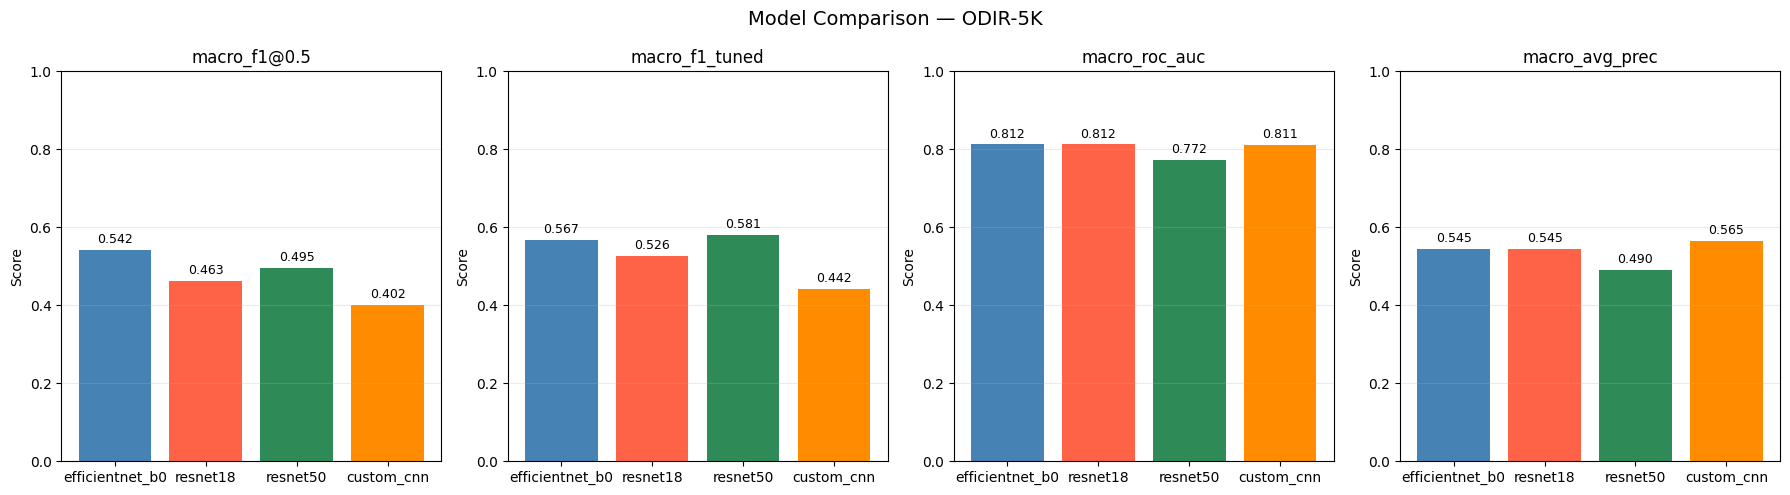

Saved to model_comparison.csv


In [95]:
# ── Final Model Comparison ─────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results).T
results_df = results_df.astype(float).round(4)

print("\n" + "="*70)
print("  FINAL MODEL COMPARISON — ODIR-5K Multi-Label Classification")
print("="*70)
print(results_df.to_string())
print("="*70)

# ── Bar chart comparison ───────────────────────────────────────────────────────
metrics_to_plot = ["macro_f1@0.5", "macro_f1_tuned", "macro_roc_auc", "macro_avg_prec"]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df[metric]
    bars = ax.bar(values.index, values.values, color=["steelblue", "tomato", "seagreen", "darkorange"])
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.25)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Model Comparison — ODIR-5K", fontsize=14)
plt.tight_layout()
plt.show()

# ── Save comparison to CSV ─────────────────────────────────────────────────────
results_df.to_csv("/kaggle/working/checkpoints/model_comparison.csv")
print("Saved to model_comparison.csv")